In [3]:
# Import required libraries
import cv2                    # OpenCV for image processing
import numpy as np            # Numerical operations
import matplotlib.pyplot as plt  # Display images
from scipy import stats       # For statistical operations (mode filter)
from google.colab import files  # To upload image in Colab

Upload an image:


Saving c_girl.jpeg to c_girl (1).jpeg


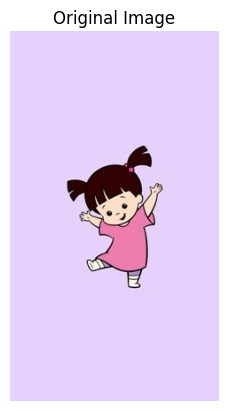


Choose option:
1. Apply Selected Filters
2. Apply ALL Filters
Enter choice: 2

--- All Filters Individual Outputs ---


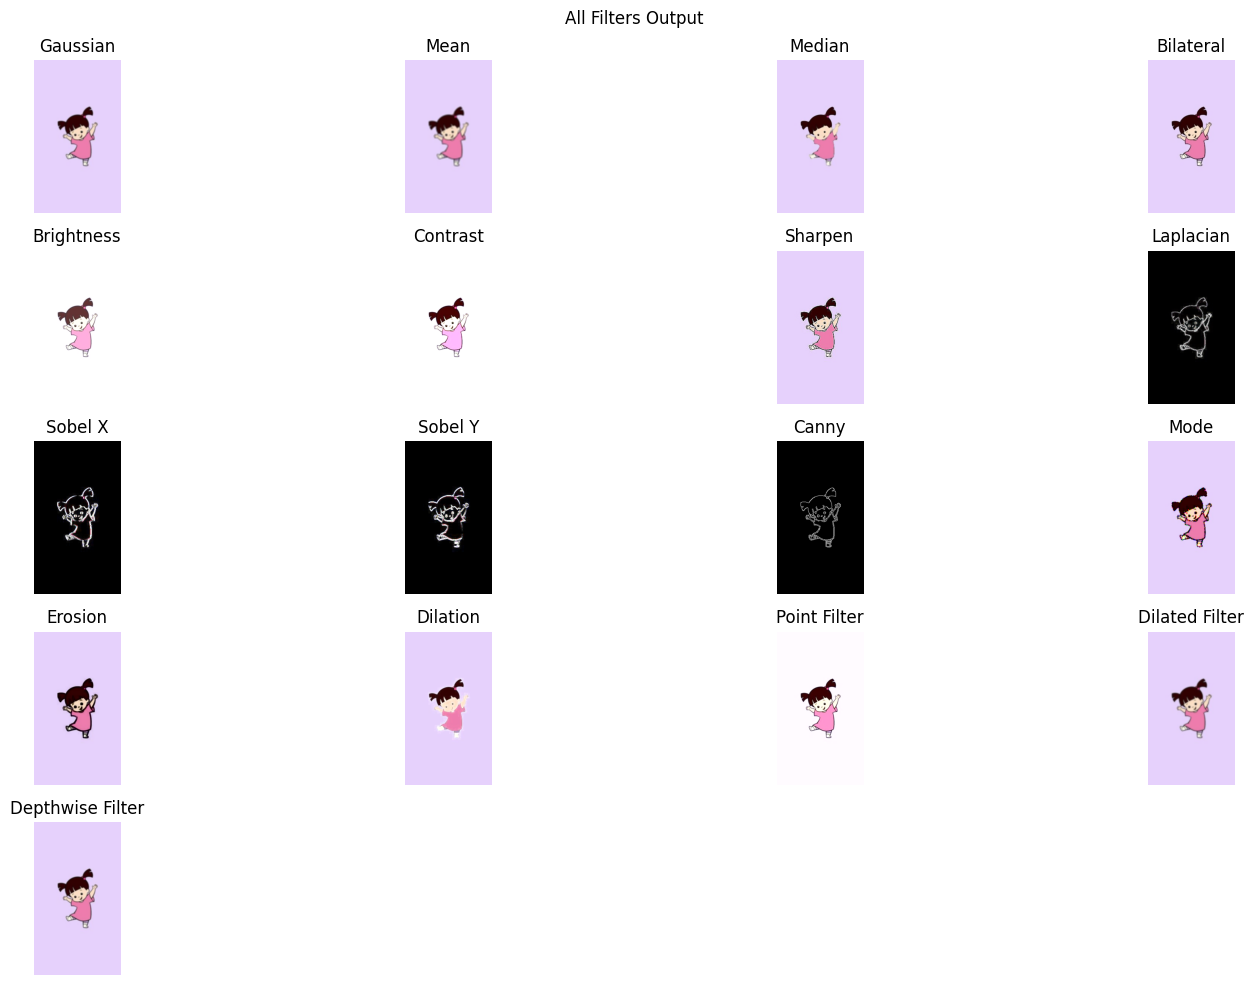


--- Combined Output (All Filters Sequential) ---


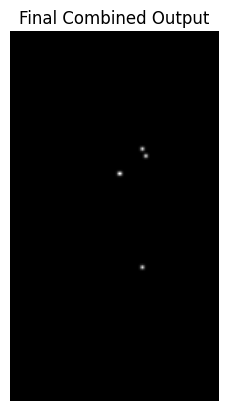

In [2]:
# ===============================
# IMAGE FILTER SYSTEM (FINAL)
# ===============================

# -------------------------------
# LOAD IMAGE
# -------------------------------
def load_image():
    # Ask user to upload an image
    print("Upload an image:")
    uploaded = files.upload()

    # Check if no file is uploaded
    if not uploaded:
        print("No image uploaded!")
        return None

    # Get uploaded file name and data
    filename = list(uploaded.keys())[0]
    img_data = uploaded[filename]

    # Convert uploaded bytes into numpy array
    nparr = np.frombuffer(img_data, np.uint8)

    # Decode numpy array into image
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    # Check if image is valid
    if img is None:
        print(f"Error: Could not decode image '{filename}'. Please ensure it is a valid image file.")
        return None

    # Convert BGR (OpenCV default) to RGB for correct display
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# -------------------------------
# FILTERS
# -------------------------------

# Gaussian Blur → smooths image and reduces noise
def gaussian(img): return cv2.GaussianBlur(img, (5,5), 0)

# Mean Filter → average smoothing
def mean(img): return cv2.blur(img, (5,5))

# Median Filter → removes salt-and-pepper noise
def median(img): return cv2.medianBlur(img, 5)

# Bilateral Filter → smooths but preserves edges
def bilateral(img): return cv2.bilateralFilter(img, 9, 75, 75)

# Increase brightness
def brightness(img): return cv2.convertScaleAbs(img, alpha=1, beta=50)

# Increase contrast
def contrast(img): return cv2.convertScaleAbs(img, alpha=1.5, beta=0)

# Sharpen image using convolution kernel
def sharpen(img):
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    return cv2.filter2D(img, -1, kernel)

# Laplacian → detects edges using second derivative
def laplacian(img): return cv2.convertScaleAbs(cv2.Laplacian(img, cv2.CV_64F))

# Sobel X → detects vertical edges
def sobelx(img): return cv2.convertScaleAbs(cv2.Sobel(img, cv2.CV_64F, 1, 0))

# Sobel Y → detects horizontal edges
def sobely(img): return cv2.convertScaleAbs(cv2.Sobel(img, cv2.CV_64F, 0, 1))

# Canny → advanced edge detection algorithm
def canny(img): return cv2.Canny(img, 100, 200)

# Mode Filter → replaces pixel with most frequent value in neighborhood
def mode_filter(img):

    # If grayscale image
    if len(img.shape) == 2:
        ch = img
        res = np.zeros_like(ch)

        # Pad image to handle borders
        ch_padded = np.pad(ch, 1, mode='edge')

        # Apply 3x3 window
        for i in range(1, ch_padded.shape[0]-1):
            for j in range(1, ch_padded.shape[1]-1):
                window = ch_padded[i-1:i+2, j-1:j+2]

                # Get most frequent value
                mode_val = stats.mode(window, axis=None)[0]
                res[i-1,j-1] = mode_val

        return res

    # If color image (process each channel separately)
    else:
        filtered = np.zeros_like(img)

        for c in range(3):
            ch = img[:,:,c]
            res = np.zeros_like(ch)
            ch_padded = np.pad(ch, 1, mode='edge')

            for i in range(1, ch_padded.shape[0]-1):
                for j in range(1, ch_padded.shape[1]-1):
                    window = ch_padded[i-1:i+2, j-1:j+2]
                    mode_val = stats.mode(window, axis=None)[0]
                    res[i-1,j-1] = mode_val

            filtered[:,:,c] = res

        return filtered


# Erosion → shrinks bright regions
def erosion(img):
    return cv2.erode(img, np.ones((3,3), np.uint8))

# Dilation → expands bright regions
def dilation(img):
    return cv2.dilate(img, np.ones((3,3), np.uint8))

# Point Filter → pixel-wise scaling (like brightness/contrast)
def point_filter(img, scale_factor=1.2):
    return cv2.convertScaleAbs(img, alpha=scale_factor, beta=0)

# Dilated Filter → custom kernel with gaps (simulates larger receptive field)
def dilated_filter(img, kernel_size=3, dilation_rate=2):

    # Create empty kernel
    kernel = np.zeros((kernel_size + (kernel_size - 1) * (dilation_rate - 1),
                       kernel_size + (kernel_size - 1) * (dilation_rate - 1)), dtype=np.float32)

    center = (kernel.shape[0] - 1) // 2

    # Fill kernel values with spacing (dilation effect)
    for i in range(kernel_size):
        for j in range(kernel_size):
            if i == 1 and j == 1:
                kernel[center + (i - 1) * dilation_rate, center + (j - 1) * dilation_rate] = 1
            elif (i == 0 or i == 2) and j == 1:
                kernel[center + (i - 1) * dilation_rate, center + (j - 1) * dilation_rate] = 0.2
            elif (j == 0 or j == 2) and i == 1:
                kernel[center + (i - 1) * dilation_rate, center + (j - 1) * dilation_rate] = 0.2
            else:
                kernel[center + (i - 1) * dilation_rate, center + (j - 1) * dilation_rate] = 0.1

    # Normalize kernel
    kernel = kernel / np.sum(kernel)

    # Apply convolution
    return cv2.filter2D(img, -1, kernel)


# Depthwise Filter → apply filter independently on each channel
def depthwise_filter(img, kernel_size=3):

    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)

    # If grayscale
    if len(img.shape) == 2:
        return cv2.filter2D(img, -1, kernel)

    # If color image
    else:
        filtered_channels = []

        # Process each channel separately
        for c in range(img.shape[2]):
            channel = img[:, :, c]
            filtered_channel = cv2.filter2D(channel, -1, kernel)
            filtered_channels.append(filtered_channel)

        return cv2.merge(filtered_channels)


# -------------------------------
# FILTER DICTIONARY
# -------------------------------
# Maps menu numbers to filter names and functions
filters = {
    "1": ("Gaussian", gaussian),
    "2": ("Mean", mean),
    "3": ("Median", median),
    "4": ("Bilateral", bilateral),
    "5": ("Brightness", brightness),
    "6": ("Contrast", contrast),
    "7": ("Sharpen", sharpen),
    "8": ("Laplacian", laplacian),
    "9": ("Sobel X", sobelx),
    "10": ("Sobel Y", sobely),
    "11": ("Canny", canny),
    "12": ("Mode", mode_filter),
    "13": ("Erosion", erosion),
    "14": ("Dilation", dilation),
    "15": ("Point Filter", point_filter),
    "16": ("Dilated Filter", dilated_filter),
    "17": ("Depthwise Filter", depthwise_filter)
}


# -------------------------------
# DISPLAY
# -------------------------------
# Function to display image using matplotlib
def show(img, title):
    plt.imshow(img, cmap='gray' if len(img.shape)==2 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()


# -------------------------------
# MAIN
# -------------------------------
# Load image from user
img = load_image()

if img is None:
    print("Error loading image")
else:
    # Show original image
    show(img, "Original Image")

    # Ask user for choice
    print("\nChoose option:")
    print("1. Apply Selected Filters")
    print("2. Apply ALL Filters")

    choice = input("Enter choice: ")

    # OPTION 1: Selected filters
    if choice == "1":
        print("\nAvailable Filters:")
        for k, v in filters.items():
            print(f"{k}. {v[0]}")

        selected = input("\nEnter filter numbers (e.g., 1,6,14): ").split(",")

        # Apply each filter separately
        print("\n--- Individual Outputs ---")
        for f in selected:
            f = f.strip()
            if f in filters:
                name, func = filters[f]
                out = func(img.copy())
                show(out, name)

        # Apply filters sequentially (combined output)
        print("\n--- Combined Output (Sequential) ---")
        combined = img.copy()
        for f in selected:
            f = f.strip()
            if f in filters:
                _, func = filters[f]
                combined = func(combined)

        show(combined, "Combined Output")

    # OPTION 2: Apply all filters
    elif choice == "2":

        print("\n--- All Filters Individual Outputs ---")

        results = []

        # Apply all filters separately
        for key, (name, func) in filters.items():
            out = func(img.copy())
            results.append((name, out))

        # Display all outputs in grid
        plt.figure(figsize=(15,10))
        num_filters = len(filters)
        rows = int(np.ceil(num_filters / 4))

        for i, (name, out) in enumerate(results):
            plt.subplot(rows, 4, i+1)
            plt.imshow(out, cmap='gray' if len(out.shape)==2 else None)
            plt.title(name)
            plt.axis("off")

        plt.suptitle("All Filters Output")
        plt.tight_layout()
        plt.show()

        # Apply all filters sequentially
        print("\n--- Combined Output (All Filters Sequential) ---")
        combined = img.copy()

        for _, func in filters.values():
            combined = func(combined)

        show(combined, "Final Combined Output")

    else:
        print("Invalid choice!")